# 02 · Node Classification — GCN on Cora

> 🎬 **Watch first:** [The GCN formula, term by term](https://youtu.be/eqmp7V0I0cw) ·
> [GAT — which neighbors matter](https://youtu.be/0EdsNkNlaZo)

**Task:** given a citation graph where only ~140 of 2,708 papers are labelled, predict every paper's topic.
This is **transductive** learning — the whole graph (features + edges) is visible; only test *labels* are hidden.

**Models & sources**
- **GCN** — Kipf & Welling, ICLR 2017 ([arXiv:1609.02907](https://arxiv.org/abs/1609.02907))
- **GAT** (attention over neighbours) — Veličković et al., ICLR 2018 ([arXiv:1710.10903](https://arxiv.org/abs/1710.10903))
- **GraphSAGE** (inductive, sampling) — Hamilton et al., NeurIPS 2017 ([arXiv:1706.02216](https://arxiv.org/abs/1706.02216))
- **Cora** dataset — Planetoid splits, Yang et al., ICML 2016 ([arXiv:1603.08861](https://arxiv.org/abs/1603.08861))

In [1]:
import sys, os
ROOT = os.getcwd()
if os.path.basename(ROOT) == "notebooks":
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # safe Apple-GPU fallback

import torch
from utils.device import get_device, device_report
device = get_device()
print(device_report())


Selected device : MPS
CUDA GPU        : not available
Apple MPS (Metal): available
CPU threads     : 4


In [2]:
from torch_geometric.datasets import Planetoid
# reuse the dataset already downloaded by the 02 module (no re-download)
dataset = Planetoid(root=os.path.join(ROOT, "02_node_classification", "data", "Cora"), name="Cora")
data = dataset[0].to(device)
print(f"{data.num_nodes} nodes | {data.num_edges} edges | "
      f"{dataset.num_features} features | {dataset.num_classes} classes")
print("labelled for training:", int(data.train_mask.sum()), "nodes")

2708 nodes | 10556 edges | 1433 features | 7 classes
labelled for training: 140 nodes


## A 2-layer GCN
Two layers = each node sees its 2-hop neighbourhood. We use `log_softmax` + `nll_loss`, dropout for regularization,
and select the model by **validation** accuracy (reporting test accuracy at the best val epoch).

In [3]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, out_dim)
    def forward(self, x, edge_index, return_emb=False):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=0.5, training=self.training)
        emb = self.conv2(h, edge_index)
        return emb if return_emb else F.log_softmax(emb, dim=1)

model = GCN(dataset.num_features, 16, dataset.num_classes).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def acc(logits, mask): return (logits[mask].argmax(1) == data.y[mask]).float().mean().item()

hist = {"loss": [], "val": [], "test": []}; best_val = best_test = 0
for epoch in range(1, 201):
    model.train(); opt.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward(); opt.step()
    model.eval()
    with torch.no_grad(): logits = model(data.x, data.edge_index)
    va, te = acc(logits, data.val_mask), acc(logits, data.test_mask)
    hist["loss"].append(loss.item()); hist["val"].append(va); hist["test"].append(te)
    if va > best_val: best_val, best_test = va, te
    if epoch % 40 == 0: print(f"epoch {epoch:3d} | loss {loss:.3f} | val {va:.3f} | test {te:.3f}")
print(f"\nBest val {best_val:.3f} -> test {best_test:.3f}")

epoch  40 | loss 0.067 | val 0.794 | test 0.802
epoch  80 | loss 0.032 | val 0.788 | test 0.802


epoch 120 | loss 0.033 | val 0.780 | test 0.794
epoch 160 | loss 0.028 | val 0.776 | test 0.797


epoch 200 | loss 0.045 | val 0.770 | test 0.794

Best val 0.806 -> test 0.810


## Training curves

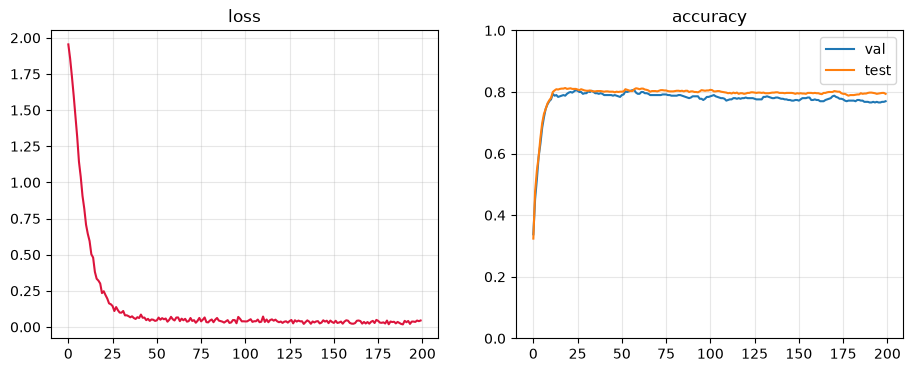

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(hist["loss"], color="crimson"); ax[0].set_title("loss"); ax[0].grid(alpha=.3)
ax[1].plot(hist["val"], label="val"); ax[1].plot(hist["test"], label="test")
ax[1].set_title("accuracy"); ax[1].set_ylim(0,1); ax[1].legend(); ax[1].grid(alpha=.3); plt.show()

## The payoff: do the learned embeddings separate the 7 topics?
We project the final-layer node embeddings to 2D with **t-SNE**. Before training this is a blob; after training it's
7 clean islands — visual proof the GNN learned meaningful representations from graph structure + text features.

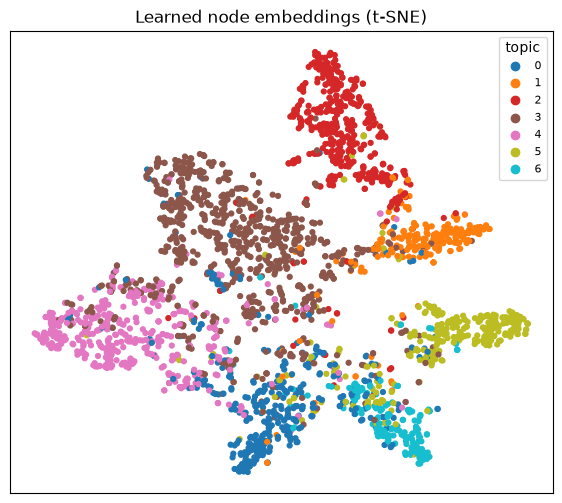

In [5]:
from sklearn.manifold import TSNE
model.eval()
with torch.no_grad():
    emb = model(data.x, data.edge_index, return_emb=True).cpu().numpy()
proj = TSNE(n_components=2, init="pca", random_state=42).fit_transform(emb)
plt.figure(figsize=(7,6))
sc = plt.scatter(proj[:,0], proj[:,1], c=data.y.cpu(), cmap="tab10", s=12)
plt.legend(*sc.legend_elements(), title="topic", fontsize=8); plt.xticks([]); plt.yticks([])
plt.title("Learned node embeddings (t-SNE)"); plt.show()

## ✅ Notes & exercises
- Expect **~80% test accuracy**. Try editing the model to `GATConv`/`SAGEConv` and compare.
- Add a third `GCNConv` layer → accuracy often *drops* (over-smoothing).
- The CLI version with GAT/SAGE + saved plots: `python 02_node_classification/train.py --model gat`.

➡ Next: **03 · Graph Classification**.